# **Mini Project 3: Retail Sales Dashboard**

# Phase 1: Data Reconnaissance & Cleaning

## Objective

In this phase, we will:

- Import the required libraries.
- Load the GlobalMart sales dataset.
- Inspect the dataset.
- Identify missing values.
- Clean the dataset by filling missing values.
- Create new features required for analysis.
- Convert the Date column into datetime format.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("supermarket_sales.csv")

df.head() 
print(df.head())

print(df.isnull().sum()) 

median_price = df["Unit price"].median()

df.fillna({"Unit price": median_price}, inplace=True) 

df["Total"] = df["Unit price"] * df["Quantity"] 

df["Date"] = pd.to_datetime(df["Date"]) 

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

# Phase 2: Grouping & Aggregation

## Objective

In this phase, we summarize the dataset using the Split → Apply → Combine methodology.

We will:

- Calculate the total daily revenue.
- Calculate revenue generated by each product line.
- Sort product lines from highest to lowest revenue.

In [9]:
daily_revenue = df.groupby("Date")["Total"].sum().reset_index()

print(daily_revenue) 

product_revenue = (
    df.groupby("Product line")["Total"].sum().reset_index().sort_values(by="Total", ascending=False)) 

print(product_revenue)
 

         Date    Total
0  2019-01-01  4519.22
1  2019-01-02  1852.86
2  2019-01-03  1979.17
3  2019-01-04  1546.37
4  2019-01-05  3368.27
..        ...      ...
84 2019-03-26  1869.06
85 2019-03-27  2764.59
86 2019-03-28  2123.24
87 2019-03-29  3831.66
88 2019-03-30  4273.39

[89 rows x 2 columns]
             Product line     Total
2      Food and beverages  53471.28
5       Sports and travel  52497.93
0  Electronic accessories  51750.03
1     Fashion accessories  51719.90
4      Home and lifestyle  51297.06
3       Health and beauty  46851.18


# Phase 3: Dashboard Visualization

## Objective

In this phase, we create a business dashboard using Matplotlib and Seaborn.

The dashboard consists of four visualizations:

- 📈 Daily Revenue Trend
- 📊 Revenue by Product Line
- 📦 Transaction Distribution by Branch
- 🔴 Relationship between Unit Price and Customer Rating

These visualizations help stakeholders quickly understand business performance and customer behavior.

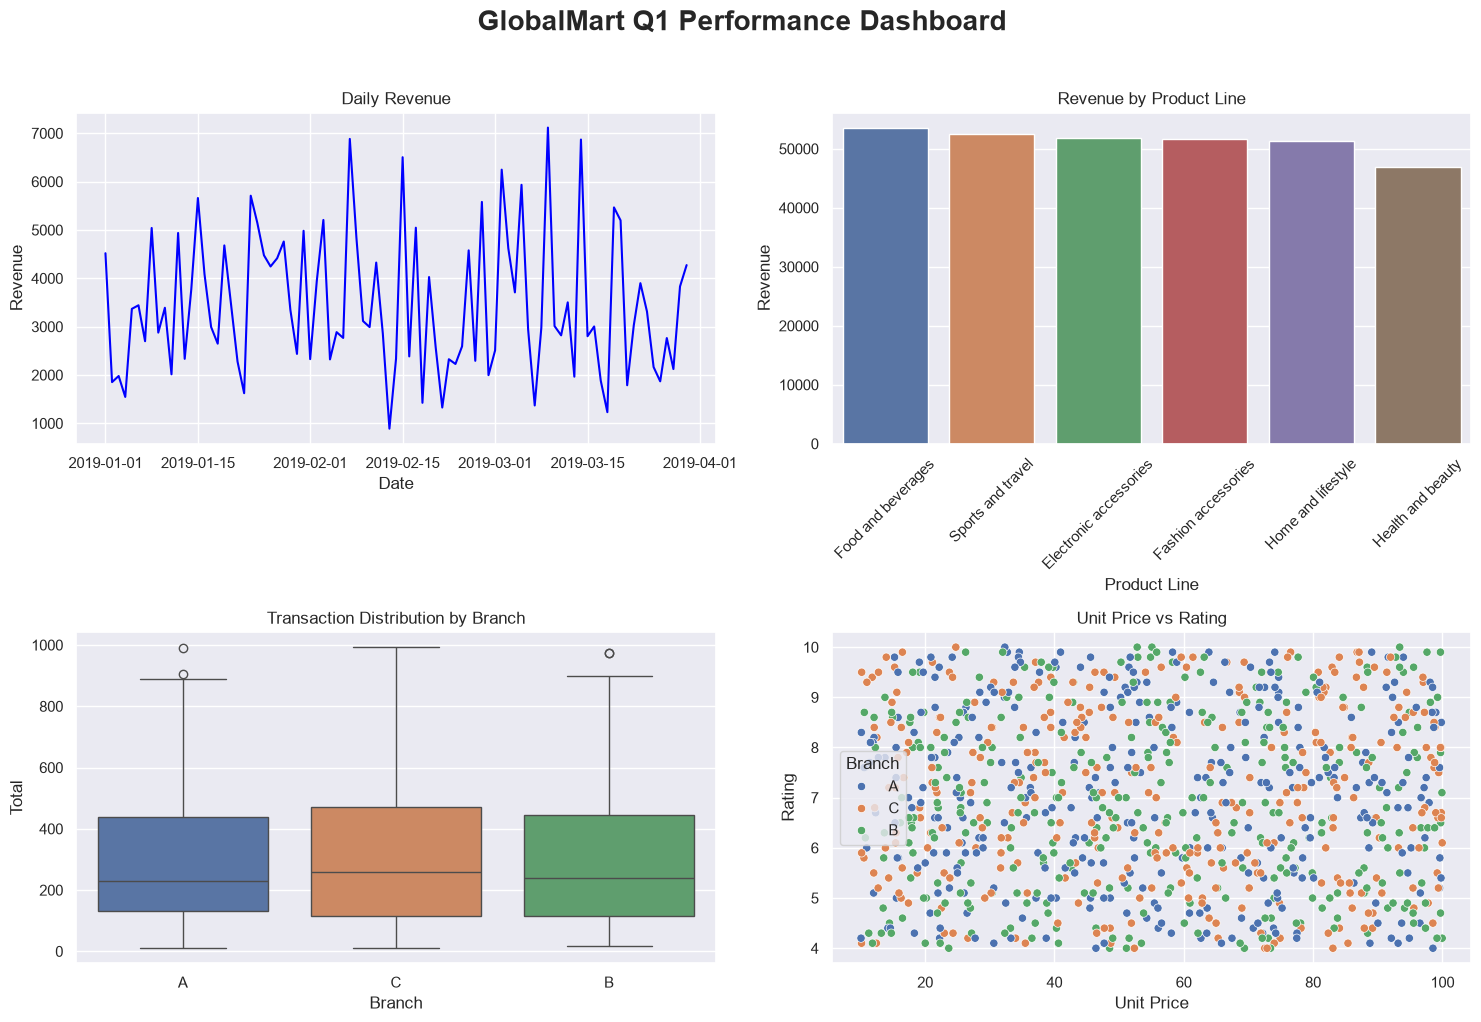

In [10]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('GlobalMart Q1 Performance Dashboard', fontsize=20, fontweight='bold', y=1.02)

axes[0,0].plot(
    daily_revenue["Date"],
    daily_revenue["Total"], color='blue')

axes[0,0].set_title("Daily Revenue")

axes[0,0].set_xlabel("Date")

axes[0,0].set_ylabel("Revenue") 


sns.barplot(
    data=product_revenue,
    x="Product line",
    y="Total",
    ax=axes[0,1], hue="Product line"
)

axes[0,1].set_title("Revenue by Product Line")

axes[0,1].set_xlabel("Product Line")

axes[0,1].set_ylabel("Revenue")

axes[0,1].tick_params(axis="x", rotation=45) 
 

sns.boxplot(
    data=df,
    x="Branch",
    y="Total",
    ax=axes[1,0],
    hue= "Branch"
)

axes[1,0].set_title("Transaction Distribution by Branch")

axes[1,0].set_xlabel("Branch")

axes[1,0].set_ylabel("Total") 


sns.scatterplot(
    data=df,
    x="Unit price",
    y="Rating",
    hue="Branch",
    ax=axes[1,1]
)

axes[1,1].set_title("Unit Price vs Rating")
axes[1,1].set_xlabel("Unit Price")
axes[1,1].set_ylabel("Rating") 



plt.tight_layout()
plt.savefig("sales_config.png" , dpi=300 ,  bbox_inches="tight")


plt.show() 

# Conclusion

**This project demonstrates how Python can be used to transform raw retail sales data into meaningful business insights.**

**After cleaning the dataset and creating new features, GroupBy operations were used to calculate daily revenue and product-wise sales performance. Finally, an interactive dashboard was built using Matplotlib and Seaborn to visualize sales trends, product performance, transaction distribution across branches, and the relationship between product pricing and customer ratings.**

**The dashboard enables stakeholders to quickly identify top-performing product lines, monitor revenue trends, compare branch performance, and better understand customer purchasing behavior. Overall, this project highlights the importance of data cleaning, aggregation, and visualization in supporting data-driven business decisions.**